In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

file_path = r"E:\vs\module 1\Assignment 1 Housing Price Prediction\HousingData.csv"
df = pd.read_csv(file_path)

df = df.dropna()

X = df.drop(columns=['MEDV']).astype(float)
y = df['MEDV'].astype(float)

print(f"Dataset Loaded Successfully! Rows: {X.shape[0]}, Features: {X.shape[1]}")
X.head()

Dataset Loaded Successfully! Rows: 394, Features: 13


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3.0,222.0,18.7,394.12,5.21


In [2]:
print("=== Basic Statistics ===")

print("\nMean:")
print(df.mean(numeric_only=True))

print("\nStandard Deviation:")
print(df.std(numeric_only=True))

print("\nCorrelation with MEDV:")
print(df.corr(numeric_only=True)['MEDV'].sort_values(ascending=False))

=== Basic Statistics ===

Mean:
CRIM         3.690136
ZN          11.460660
INDUS       11.000863
CHAS         0.068528
NOX          0.553215
RM           6.280015
AGE         68.932741
DIS          3.805268
RAD          9.403553
TAX        406.431472
PTRATIO     18.537563
B          358.490939
LSTAT       12.769112
MEDV        22.359645
dtype: float64

Standard Deviation:
CRIM         9.202423
ZN          23.954082
INDUS        6.908364
CHAS         0.252971
NOX          0.113112
RM           0.697985
AGE         27.888705
DIS          2.098571
RAD          8.633451
TAX        168.312419
PTRATIO      2.166460
B           89.283295
LSTAT        7.308430
MEDV         9.142979
dtype: float64

Correlation with MEDV:
MEDV       1.000000
RM         0.723951
ZN         0.406822
B          0.347256
DIS        0.279547
CHAS       0.173701
CRIM      -0.397230
AGE       -0.407470
RAD       -0.416638
NOX       -0.459054
TAX       -0.508864
INDUS     -0.510829
PTRATIO   -0.543809
LSTAT     -0.7434

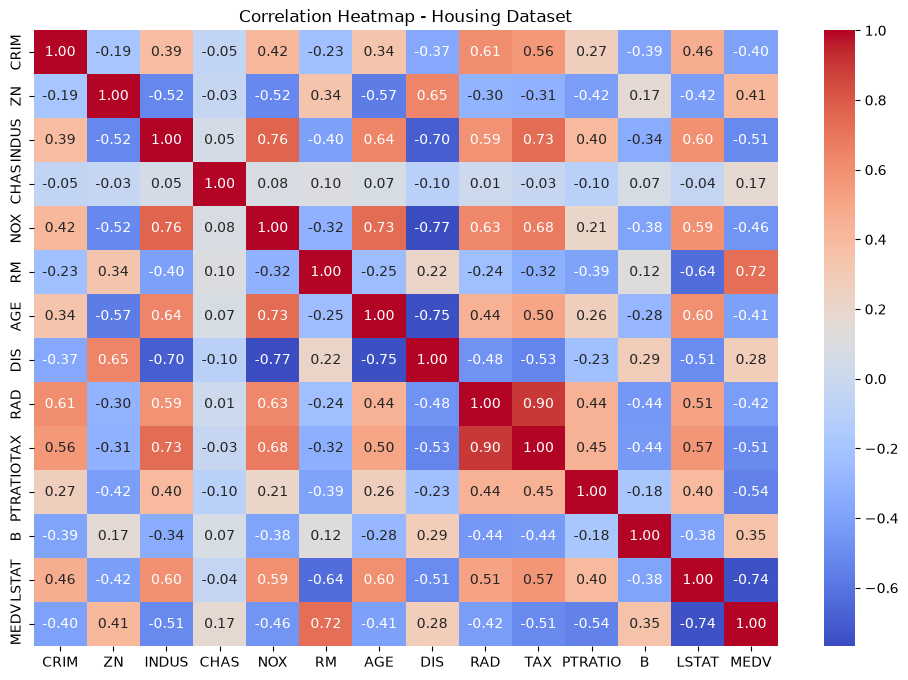

In [3]:

plt.figure(figsize=(12, 8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap - Housing Dataset")
plt.show()

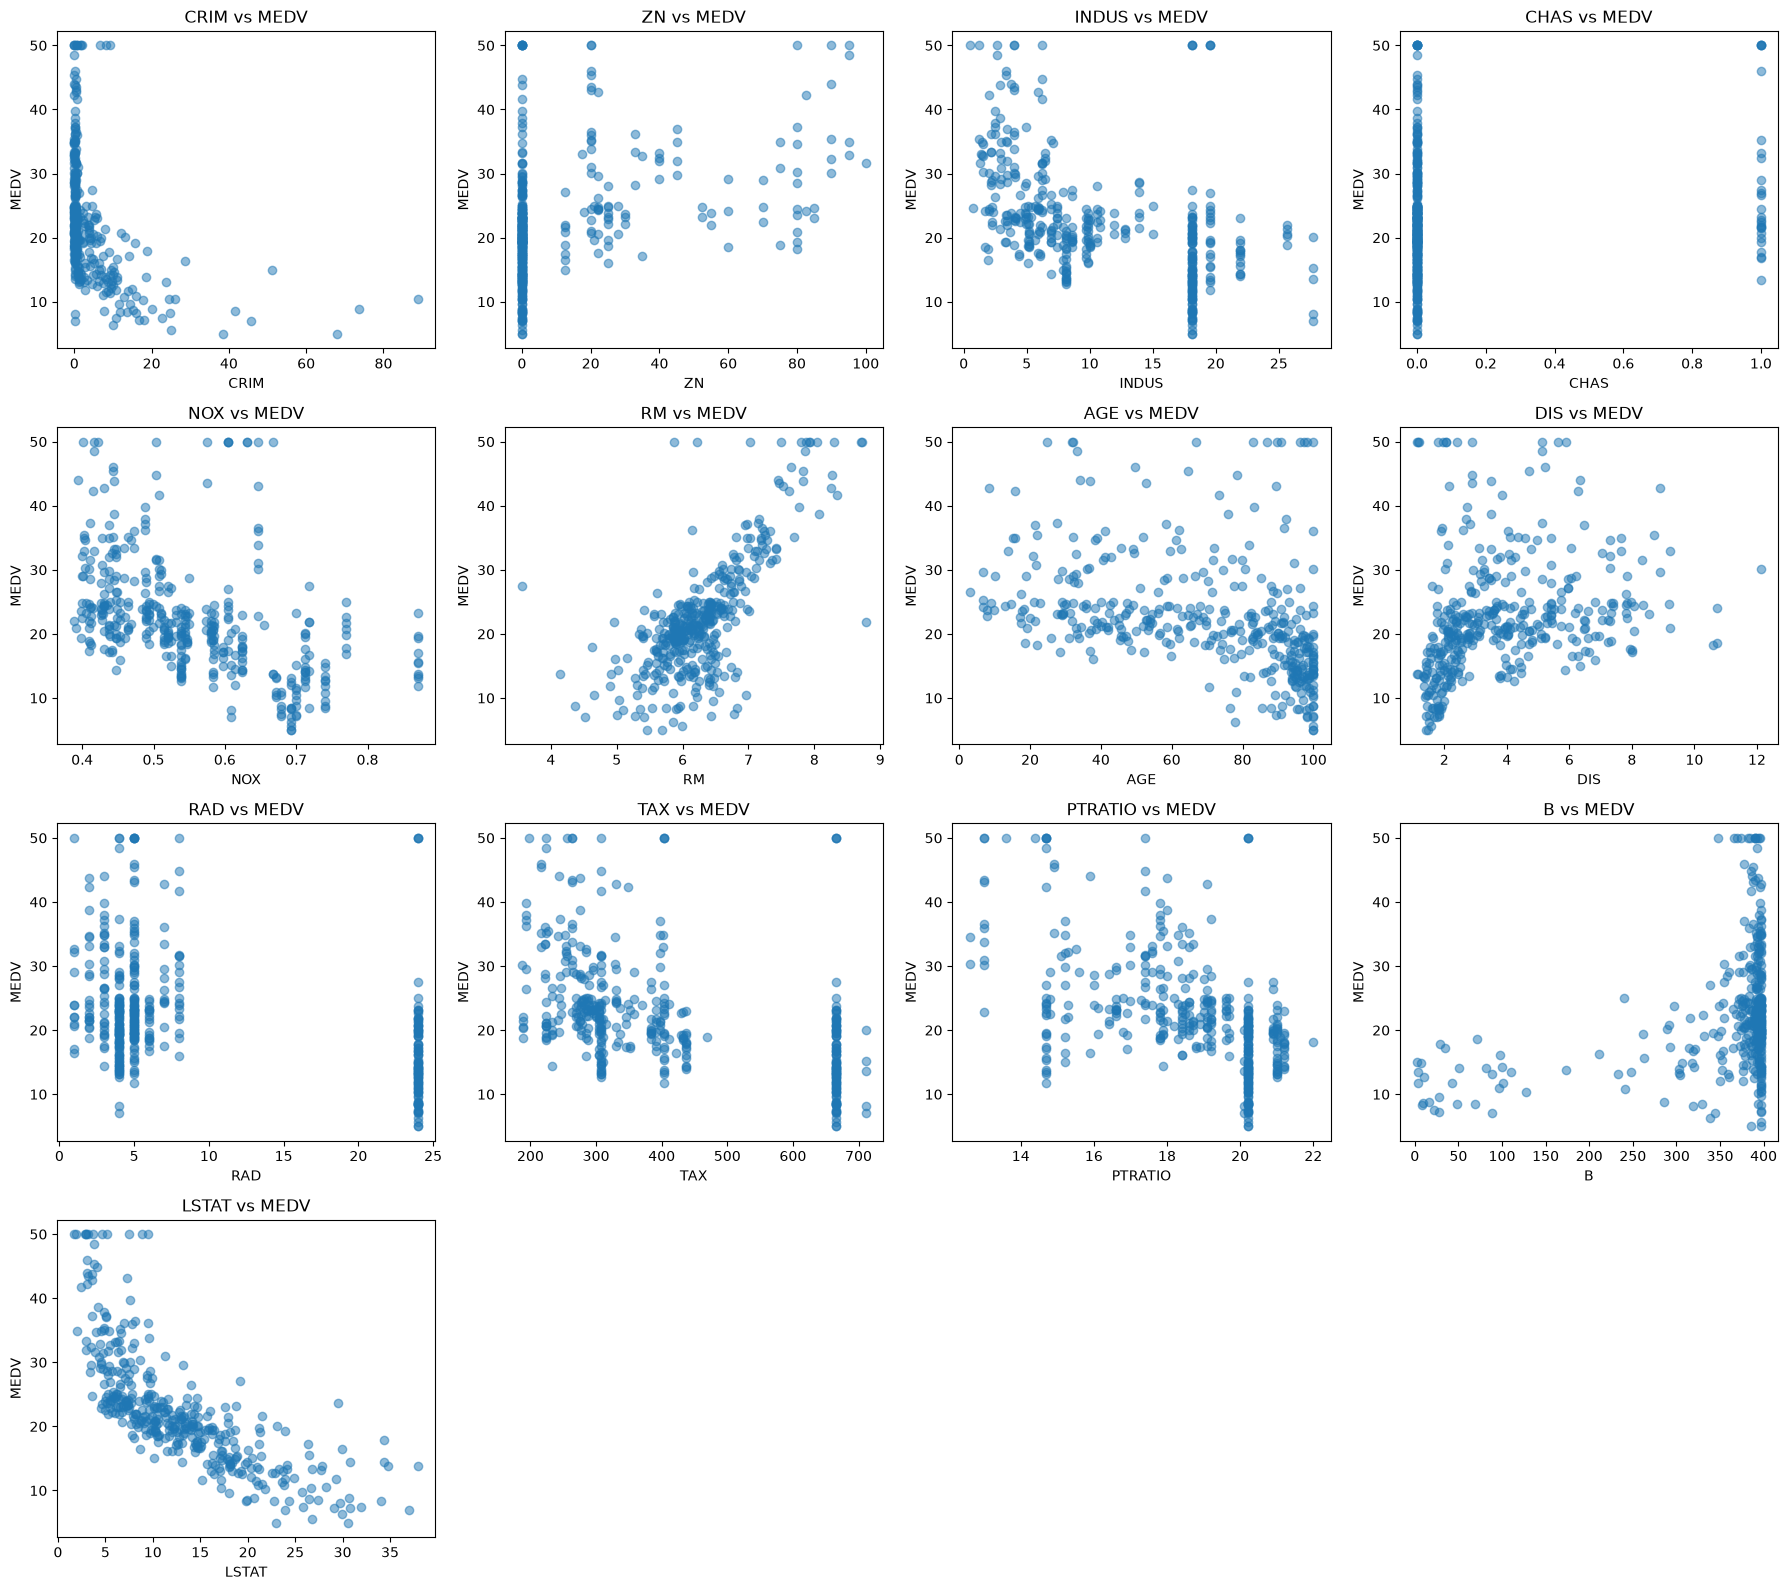

In [4]:

features = X.columns

fig, axes = plt.subplots(4,4, figsize=(18, 16))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(X[feature], y, alpha=0.5)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("MEDV")
    axes[i].set_title(f"{feature} vs MEDV")

# Hide unused plots
for i in range(len(features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [5]:

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42
)

print("=== Dataset Split ===")
print(f"Total samples      : {len(X)}")
print(f"Training samples   : {len(X_train)}")
print(f"Validation samples : {len(X_val)}")
print(f"Testing samples    : {len(X_test)}")

print("\nSplit Percentage:")
print(f"Training   : {len(X_train)/len(X)*100:.1f}%")
print(f"Validation : {len(X_val)/len(X)*100:.1f}%")
print(f"Testing    : {len(X_test)/len(X)*100:.1f}%")

=== Dataset Split ===
Total samples      : 394
Training samples   : 236
Validation samples : 79
Testing samples    : 79

Split Percentage:
Training   : 59.9%
Validation : 20.1%
Testing    : 20.1%


In [6]:
#Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

print("\nScaled Training Data Shape:", X_train_scaled.shape)
print("Scaled Validation Data Shape:", X_val_scaled.shape)
print("Scaled Testing Data Shape:", X_test_scaled.shape)

Feature scaling completed successfully!

Scaled Training Data Shape: (236, 13)
Scaled Validation Data Shape: (79, 13)
Scaled Testing Data Shape: (79, 13)


In [7]:
#Gradient Descent from Scratch

def gradient_descent(X, y, learning_rate=0.01, iterations=5000):
    
    n_samples, n_features = X.shape
    
    # Initialize weights and bias
    weights = np.zeros(n_features)
    bias = 0
    
    cost_history = []
    
    for i in range(iterations):
        
        # Prediction
        y_pred = np.dot(X, weights) + bias
        
        # Error
        error = y_pred - y
        
        # Cost function (Mean Squared Error / 2)
        cost = np.mean(error ** 2) / 2
        cost_history.append(cost)
        
        # Gradients
        dw = (1 / n_samples) * np.dot(X.T, error)
        db = (1 / n_samples) * np.sum(error)
        
        # Update weights and bias
        weights = weights - learning_rate * dw
        bias = bias - learning_rate * db
    
    return weights, bias, cost_history


print("Gradient Descent function created successfully!")

Gradient Descent function created successfully!


In [8]:

import time

start_time = time.time()

gd_weights, gd_bias, cost_history = gradient_descent(
    X_train_scaled,
    y_train.values,
    learning_rate=0.01,
    iterations=5000
)

gd_training_time = time.time() - start_time

print("=== Gradient Descent Results ===")

print("\nTraining Time:", round(gd_training_time, 4), "seconds")

print("\nFinal Bias:")
print(round(gd_bias, 4))

print("\nFinal Weights:")
for feature, weight in zip(X.columns, gd_weights):
    print(f"{feature}: {weight:.4f}")

print("\nFinal Cost:")
print(round(cost_history[-1], 4))

=== Gradient Descent Results ===

Training Time: 0.1463 seconds

Final Bias:
21.9081

Final Weights:
CRIM: -1.0560
ZN: 0.6580
INDUS: 0.2958
CHAS: 0.8148
NOX: -1.7810
RM: 3.7604
AGE: -0.8304
DIS: -2.8139
RAD: 1.6615
TAX: -1.7663
PTRATIO: -1.9023
B: 0.7793
LSTAT: -2.5725

Final Cost:
8.0428


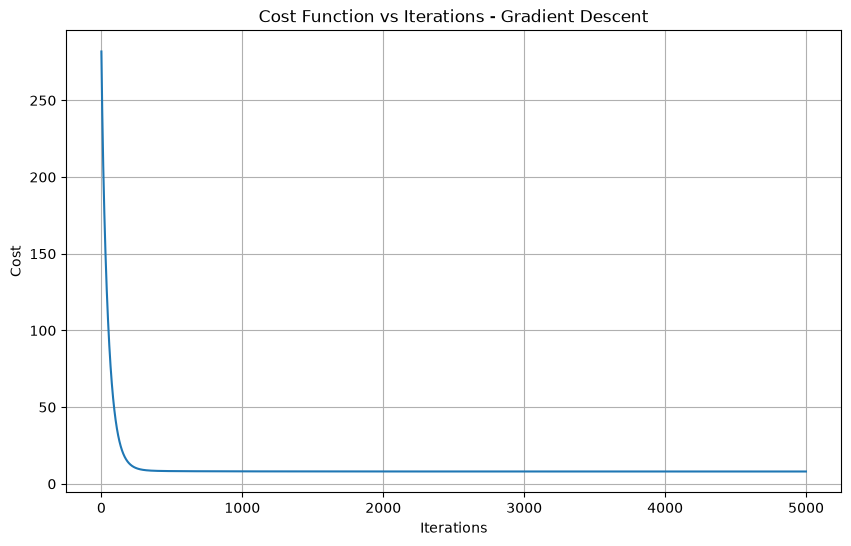

In [9]:

plt.figure(figsize=(10, 6))

plt.plot(cost_history)

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function vs Iterations - Gradient Descent")

plt.grid(True)
plt.show()

In [10]:

start_time = time.time()

X_train_with_bias = np.c_[
    np.ones(X_train_scaled.shape[0]),
    X_train_scaled
]



normal_weights = np.linalg.pinv(
    X_train_with_bias.T @ X_train_with_bias
) @ X_train_with_bias.T @ y_train.values

normal_training_time = time.time() - start_time

normal_bias = normal_weights[0]
normal_feature_weights = normal_weights[1:]

print("=== Normal Equation Results ===")

print("\nTraining Time:", round(normal_training_time, 4), "seconds")

print("\nFinal Bias:")
print(round(normal_bias, 4))

print("\nFinal Weights:")
for feature, weight in zip(X.columns, normal_feature_weights):
    print(f"{feature}: {weight:.4f}")

=== Normal Equation Results ===

Training Time: 0.002 seconds

Final Bias:
21.9081

Final Weights:
CRIM: -1.0631
ZN: 0.6739
INDUS: 0.3329
CHAS: 0.8104
NOX: -1.7974
RM: 3.7519
AGE: -0.8251
DIS: -2.8241
RAD: 1.7423
TAX: -1.8623
PTRATIO: -1.9038
B: 0.7783
LSTAT: -2.5754


In [11]:

print("=== Gradient Descent vs Normal Equation ===")

print("\nTraining Time:")
print(f"Gradient Descent : {gd_training_time:.6f} seconds")
print(f"Normal Equation  : {normal_training_time:.6f} seconds")

print("\nBias / Intercept:")
print(f"Gradient Descent : {gd_bias:.4f}")
print(f"Normal Equation  : {normal_bias:.4f}")

print("\nFinal Weights Comparison:")

comparison = pd.DataFrame({
    "Feature": X.columns,
    "Gradient Descent": gd_weights,
    "Normal Equation": normal_feature_weights
})

print(comparison.to_string(index=False))

=== Gradient Descent vs Normal Equation ===

Training Time:
Gradient Descent : 0.146308 seconds
Normal Equation  : 0.002013 seconds

Bias / Intercept:
Gradient Descent : 21.9081
Normal Equation  : 21.9081

Final Weights Comparison:
Feature  Gradient Descent  Normal Equation
   CRIM         -1.056047        -1.063121
     ZN          0.657980         0.673933
  INDUS          0.295788         0.332942
   CHAS          0.814812         0.810430
    NOX         -1.780996        -1.797367
     RM          3.760397         3.751902
    AGE         -0.830381        -0.825107
    DIS         -2.813860        -2.824092
    RAD          1.661538         1.742302
    TAX         -1.766325        -1.862279
PTRATIO         -1.902280        -1.903792
      B          0.779317         0.778319
  LSTAT         -2.572516        -2.575433


In [12]:

correlations = df.corr(numeric_only=True)["MEDV"].drop("MEDV")

selected_feature = correlations.abs().idxmax()

print("=== Polynomial Feature Experiment ===")
print("Selected Feature:", selected_feature)
print("Correlation with MEDV:", round(correlations[selected_feature], 4))

=== Polynomial Feature Experiment ===
Selected Feature: LSTAT
Correlation with MEDV: -0.7434


Degree 1:
  Training MSE   : 35.3451
  Validation MSE : 31.6829

Degree 2:
  Training MSE   : 24.9788
  Validation MSE : 24.7518

Degree 3:
  Training MSE   : 23.8804
  Validation MSE : 23.8239

Degree 5:
  Training MSE   : 33.3466
  Validation MSE : 31.7265

Best Polynomial Degree: 3


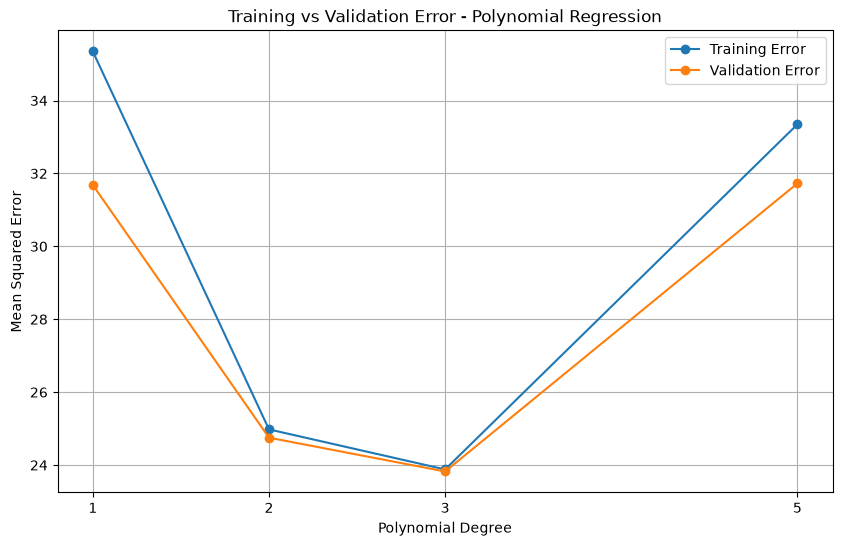

In [13]:

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

degrees = [1, 2, 3,5]

train_errors = []
val_errors = []

for degree in degrees:

    # Create polynomial features
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    X_train_poly = poly.fit_transform(
        X_train[[selected_feature]]
    )

    X_val_poly = poly.transform(
        X_val[[selected_feature]]
    )

    model = LinearRegression()

    model.fit(X_train_poly, y_train)

    train_pred = model.predict(X_train_poly)
    val_pred = model.predict(X_val_poly)

    train_mse = mean_squared_error(y_train, train_pred)
    val_mse = mean_squared_error(y_val, val_pred)

    train_errors.append(train_mse)
    val_errors.append(val_mse)

    print(f"Degree {degree}:")
    print(f"  Training MSE   : {train_mse:.4f}")
    print(f"  Validation MSE : {val_mse:.4f}")
    print()


best_degree = degrees[np.argmin(val_errors)]

print("Best Polynomial Degree:", best_degree)


plt.figure(figsize=(10, 6))

plt.plot(
    degrees,
    train_errors,
    marker="o",
    label="Training Error"
)

plt.plot(
    degrees,
    val_errors,
    marker="o",
    label="Validation Error"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Training vs Validation Error - Polynomial Regression")

plt.xticks(degrees)
plt.legend()
plt.grid(True)

plt.show()

Training Size: 50
Training MSE   : 12.2189
Validation MSE : 31.6831

Training Size: 100
Training MSE   : 12.7428
Validation MSE : 23.6045

Training Size: 200
Training MSE   : 16.5994
Validation MSE : 22.2296

Skipped sizes because they are larger than the training set: [300, 400]


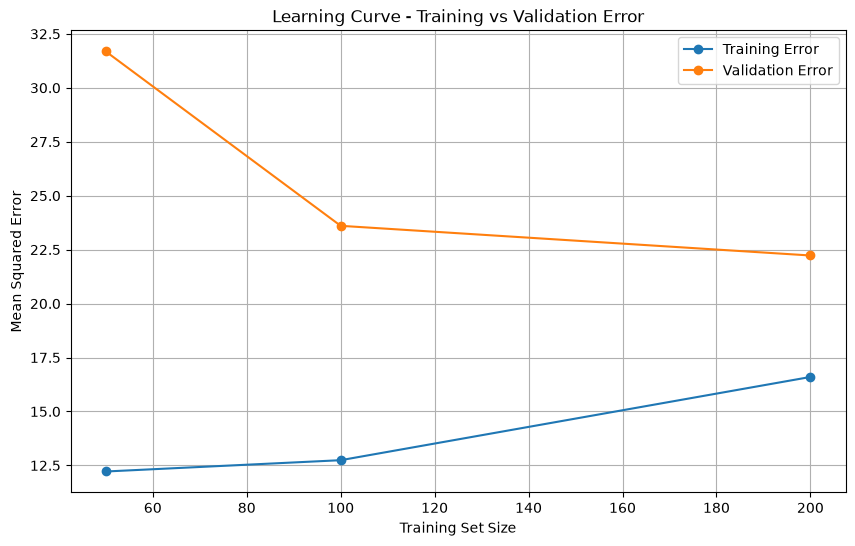

In [14]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

requested_sizes = [50, 100, 200, 300, 400]

learning_sizes = [
    size for size in requested_sizes
    if size <= len(X_train)
]

train_errors_lc = []
val_errors_lc = []

for size in learning_sizes:

    X_subset = X_train_scaled[:size]
    y_subset = y_train.values[:size]

    model = LinearRegression()
    model.fit(X_subset, y_subset)

    train_pred = model.predict(X_subset)

    val_pred = model.predict(X_val_scaled)

    train_mse = mean_squared_error(y_subset, train_pred)
    val_mse = mean_squared_error(y_val, val_pred)

    train_errors_lc.append(train_mse)
    val_errors_lc.append(val_mse)

    print(f"Training Size: {size}")
    print(f"Training MSE   : {train_mse:.4f}")
    print(f"Validation MSE : {val_mse:.4f}")
    print()


skipped_sizes = [
    size for size in requested_sizes
    if size > len(X_train)
]

if skipped_sizes:
    print("Skipped sizes because they are larger than the training set:",
          skipped_sizes)


plt.figure(figsize=(10, 6))

plt.plot(
    learning_sizes,
    train_errors_lc,
    marker="o",
    label="Training Error"
)

plt.plot(
    learning_sizes,
    val_errors_lc,
    marker="o",
    label="Validation Error"
)

plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curve - Training vs Validation Error")

plt.legend()
plt.grid(True)

plt.show()

In [15]:

print("=== Bias-Variance Analysis ===")

best_train_index = np.argmin(train_errors)
best_val_index = np.argmin(val_errors)

best_train_degree = degrees[best_train_index]
best_val_degree = degrees[best_val_index]

print("\nPolynomial Regression:")
print(f"Best degree based on Training Error   : {best_train_degree}")
print(f"Best degree based on Validation Error : {best_val_degree}")

overfitting_degree = None

for i in range(1, len(degrees)):
    
    if (train_errors[i] < train_errors[i - 1] and
        val_errors[i] > val_errors[i - 1]):
        
        overfitting_degree = degrees[i]
        break

if overfitting_degree is not None:
    print(f"\nOverfitting starts around polynomial degree: {overfitting_degree}")
else:
    print("\nClear overfitting point was not detected.")

print("\nLearning Curve Analysis:")

initial_train_error = train_errors_lc[0]
final_train_error = train_errors_lc[-1]

initial_val_error = val_errors_lc[0]
final_val_error = val_errors_lc[-1]

print(f"Initial Training Error   : {initial_train_error:.4f}")
print(f"Final Training Error     : {final_train_error:.4f}")

print(f"Initial Validation Error : {initial_val_error:.4f}")
print(f"Final Validation Error   : {final_val_error:.4f}")

print("\n=== Conclusion ===")

if overfitting_degree is not None:
    print(
        f"The polynomial model begins to overfit around degree "
        f"{overfitting_degree}, where training error continues to "
        f"decrease while validation error increases."
    )
else:
    print(
        "The experiment does not show a clear overfitting point "
        "within the tested polynomial degrees."
    )

print(
    "\nBias-Variance behavior can be studied by comparing "
    "training and validation errors. A large gap between them "
    "indicates high variance, while high errors on both indicate "
    "high bias."
)

=== Bias-Variance Analysis ===

Polynomial Regression:
Best degree based on Training Error   : 3
Best degree based on Validation Error : 3

Clear overfitting point was not detected.

Learning Curve Analysis:
Initial Training Error   : 12.2189
Final Training Error     : 16.5994
Initial Validation Error : 31.6831
Final Validation Error   : 22.2296

=== Conclusion ===
The experiment does not show a clear overfitting point within the tested polynomial degrees.

Bias-Variance behavior can be studied by comparing training and validation errors. A large gap between them indicates high variance, while high errors on both indicate high bias.


In [16]:

from sklearn.metrics import mean_squared_error, r2_score

gd_test_pred = np.dot(X_test_scaled, gd_weights) + gd_bias

normal_test_pred = (
    np.c_[
        np.ones(X_test_scaled.shape[0]),
        X_test_scaled
    ] @ normal_weights
)

gd_mse = mean_squared_error(y_test, gd_test_pred)
gd_rmse = np.sqrt(gd_mse)
gd_r2 = r2_score(y_test, gd_test_pred)

normal_mse = mean_squared_error(y_test, normal_test_pred)
normal_rmse = np.sqrt(normal_mse)
normal_r2 = r2_score(y_test, normal_test_pred)

print("=== Final Test Set Evaluation ===")

print("\nGradient Descent:")
print(f"MSE  : {gd_mse:.4f}")
print(f"RMSE : {gd_rmse:.4f}")
print(f"R²   : {gd_r2:.4f}")

print("\nNormal Equation:")
print(f"MSE  : {normal_mse:.4f}")
print(f"RMSE : {normal_rmse:.4f}")
print(f"R²   : {normal_r2:.4f}")

=== Final Test Set Evaluation ===

Gradient Descent:
MSE  : 30.2530
RMSE : 5.5003
R²   : 0.6413

Normal Equation:
MSE  : 30.2083
RMSE : 5.4962
R²   : 0.6419


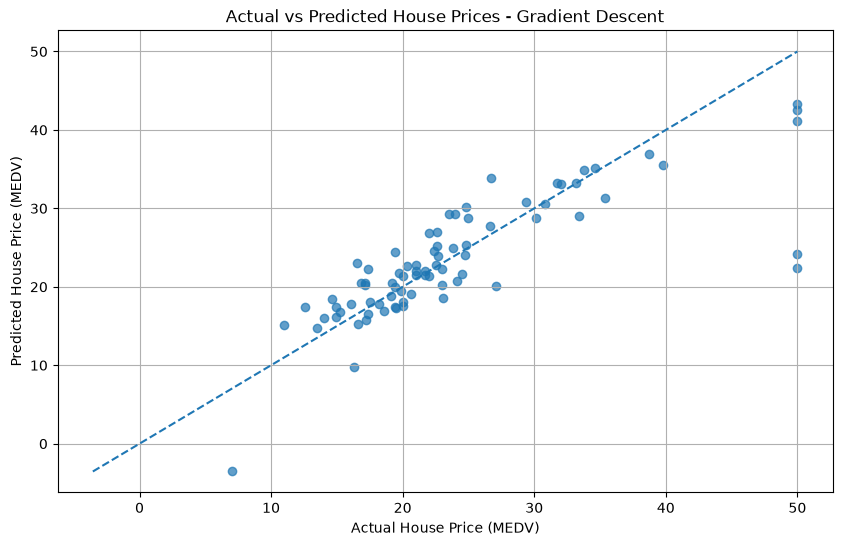

In [17]:

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    gd_test_pred,
    alpha=0.7
)

min_value = min(y_test.min(), gd_test_pred.min())
max_value = max(y_test.max(), gd_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual House Price (MEDV)")
plt.ylabel("Predicted House Price (MEDV)")
plt.title("Actual vs Predicted House Prices - Gradient Descent")

plt.grid(True)
plt.show()

In [18]:

print("=" * 60)
print("       HOUSING PRICE PREDICTION - FINAL SUMMARY")
print("=" * 60)

print("\n1. DATASET")
print(f"Total Samples       : {len(X)}")
print(f"Number of Features  : {X.shape[1]}")

print("\n2. DATA SPLIT")
print(f"Training Samples    : {len(X_train)}")
print(f"Validation Samples  : {len(X_val)}")
print(f"Testing Samples     : {len(X_test)}")

print("\n3. GRADIENT DESCENT")
print(f"Training Time       : {gd_training_time:.6f} seconds")
print(f"Final Cost          : {cost_history[-1]:.4f}")

print("\n4. NORMAL EQUATION")
print(f"Training Time       : {normal_training_time:.6f} seconds")

print("\n5. POLYNOMIAL REGRESSION")
print(f"Best Degree         : {best_val_degree}")

if overfitting_degree is not None:
    print(f"Overfitting Starts  : Degree {overfitting_degree}")
else:
    print("Overfitting         : Not clearly detected")

print("\n6. TEST PERFORMANCE")

print("\nGradient Descent:")
print(f"MSE                 : {gd_mse:.4f}")
print(f"RMSE                : {gd_rmse:.4f}")
print(f"R² Score            : {gd_r2:.4f}")

print("\nNormal Equation:")
print(f"MSE                 : {normal_mse:.4f}")
print(f"RMSE                : {normal_rmse:.4f}")
print(f"R² Score            : {normal_r2:.4f}")

print("\n7. BIAS-VARIANCE")
print("High Bias  → Model is too simple → Underfitting")
print("High Variance → Model is too complex → Overfitting")


       HOUSING PRICE PREDICTION - FINAL SUMMARY

1. DATASET
Total Samples       : 394
Number of Features  : 13

2. DATA SPLIT
Training Samples    : 236
Validation Samples  : 79
Testing Samples     : 79

3. GRADIENT DESCENT
Training Time       : 0.146308 seconds
Final Cost          : 8.0428

4. NORMAL EQUATION
Training Time       : 0.002013 seconds

5. POLYNOMIAL REGRESSION
Best Degree         : 3
Overfitting         : Not clearly detected

6. TEST PERFORMANCE

Gradient Descent:
MSE                 : 30.2530
RMSE                : 5.5003
R² Score            : 0.6413

Normal Equation:
MSE                 : 30.2083
RMSE                : 5.4962
R² Score            : 0.6419

7. BIAS-VARIANCE
High Bias  → Model is too simple → Underfitting
High Variance → Model is too complex → Overfitting
